##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose

import numpy as np
import matplotlib.pyplot as plt

from mlPlayGround.generative.normFlow import realNonVolumePreserving

###### Dequantization

In [2]:
class Dequantize:
    """
    Adds uniform noise U(0, 1/255) to pixel values, converting discrete
    integer pixel values in [0, 1] to continuous values. This prevents
    the flow from collapsing probability mass onto the data manifold.
    """
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        return x + torch.rand_like(x) / 255.0

transform = Compose([ToTensor(), Dequantize()])

###### Load data

In [3]:
class imageOnlyDataset(torch.utils.data.Dataset):
    """Strips labels — generative models don't need them."""
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        return self.dataset[index][0]


trainData = datasets.FashionMNIST(root='../data', train=True,  download=True, transform=transform)
testData  = datasets.FashionMNIST(root='../data', train=False, download=True, transform=transform)

trainImageData = imageOnlyDataset(trainData)
testImageData  = imageOnlyDataset(testData)

print(f'Train: {len(trainImageData)}  Test: {len(testImageData)}')
print(f'Image shape: {trainImageData[0].shape}')

Train: 60000  Test: 10000
Image shape: torch.Size([1, 28, 28])


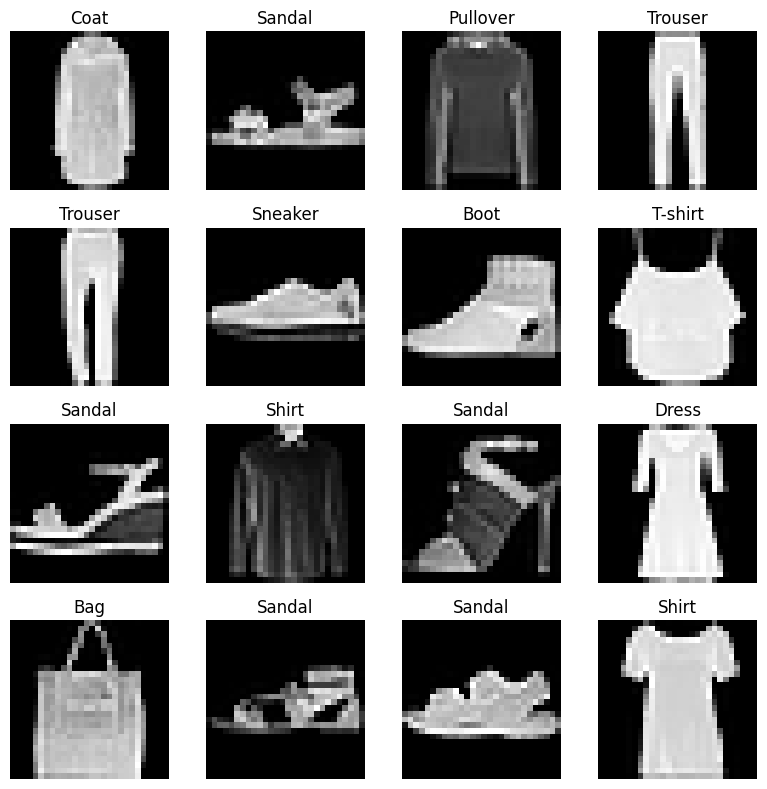

In [4]:
label_map = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
             5: 'Sandal',  6: 'Shirt',   7: 'Sneaker', 8: 'Bag',  9: 'Boot'}

figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    idx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[label])
    plt.axis('off')
    plt.imshow(img.squeeze(), cmap='gray')
plt.tight_layout()
plt.show()

###### Hardware

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce GTX 970


##### Real NVP

###### Architecture

In [6]:
class resBlock(nn.Module):
    """
    Two-layer conv ResNet block used as the scale (s) and bias (t)
    sub-networks inside each Real NVP coupling layer.
    Input and output have the same spatial dims and channel count.
    """
    def __init__(self, inChannels: int, hiddenChannels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(inChannels, hiddenChannels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hiddenChannels),
            nn.ReLU(),
            nn.Conv2d(hiddenChannels, inChannels, kernel_size=3, padding=1),
            nn.BatchNorm2d(inChannels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)

In [7]:
# Fashion-MNIST: 1 x 28 x 28
dims = (1, 28, 28)
hidden = 64
nScales = 1   # <-- tune this: each scale squeezes 28->14->7 etc.
nFinal = 4

model = realNonVolumePreserving(
    baseBlock=resBlock,
    dims=dims,
    hidden=hidden,
    nScales=nScales,
    nFinal=nFinal,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 95,754


###### Training

In [11]:
learning_rate = 1e-4
batch_size = 64
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True,  num_workers=0)
validLoader = DataLoader(testImageData,  batch_size=batch_size, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
model.trainLoop(trainLoader, optimizer, epochs,
                reportIters=100,
                checkpointPath='../checkpoints/fashionmnist_nvp/',
                checkPointName=f'nvp_scales{nScales}_h{hidden}',
                validDataLoader=validLoader)

Epoch 1
-------------------------------
totalLoss: -802.344604 logLoss: -803.763550 priorLoss: 1.418933[ 6400/60000]
totalLoss: -779.472778 logLoss: -780.891724 priorLoss: 1.418933[12800/60000]
totalLoss: -755.973022 logLoss: -757.391968 priorLoss: 1.418933[19200/60000]


###### Evaluation

In [ ]:
def bits_per_dim(model, loader, device, n_dims=784):
    """
    Computes bits per dimension on the given data loader.
    bpd = mean(-log p(x)) / (n_dims * log 2)
    Lower is better. State-of-the-art on Fashion-MNIST is ~3.7 bpd.
    """
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            loss = model.validStep(x)
            total_loss += loss.item()
            n_batches += 1

    mean_nll = total_loss / n_batches  # mean negative log-likelihood (nats)
    bpd = mean_nll / (n_dims * np.log(2))
    return bpd


n_dims = dims[0] * dims[1] * dims[2]
train_bpd = bits_per_dim(model, trainLoader, device, n_dims)
test_bpd  = bits_per_dim(model, validLoader, device, n_dims)
print(f'Train bpd: {train_bpd:.4f}')
print(f'Test  bpd: {test_bpd:.4f}')